# 06 — D6 `garch_t_vol`: GJR-GARCH(1,1)-t + umbral causal de sigma

Familia **F5 (Volatilidad)**. Detector univariante sobre el **retorno log del S&P 500**
(desde 1985). El modelo **GJR-GARCH(1,1)-t** no produce *estados tipados*: produce una
**sigma condicional** (volatilidad esperada de t dado el pasado). El régimen se define
**umbralizando** esa sigma con un percentil del train (histéresis τ_in/τ_out + dwell).

**Por qué GJR-GARCH-t:** `o=1` capta la **asimetría / leverage** (las caídas suben la
vol futura más que las subidas — Glosten-Jagannathan-Runkle 1993); `dist='t'` capta las
**colas gordas** (kurtosis 25–40 del EDA — Bollerslev 1987); base GARCH(1,1) (Bollerslev
1986) sobre el ARCH de Engle (1982). Escala ×100 recomendada por `arch` (Sheppard).

## Hipótesis CP2 (la que este notebook pone a prueba)
> *"El GARCH **no da estados tipados**; se **umbraliza la sigma**. Es **causal por
> construcción** y **reacciona EL MISMO DÍA** que llega el shock (sigma_t salta con el
> retorno de t), así que **DEBERÍA captar también las correcciones rápidas de 2013
> (taper) y 2018 (Q4)** donde el HMM gaussiano (D4) se queda corto. Univariante sobre
> equity."*

**Ventana LARGA:** al modelar solo el S&P 500 (desde 1985), el walk-forward cubre
**2008 y 2011 OUT-OF-SAMPLE** — algo que D4 (atado a HYG desde 2007) no podía.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from detectors.garch_t_vol import GarchTVol

raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
spx_ret = np.log(raw['SP500'] / raw['SP500'].shift(1)).rename('SP500_ret')
X = pd.DataFrame({'SP500_ret': spx_ret}).dropna()
X.index = pd.to_datetime(X.index); X = X.sort_index()
mkt = X['SP500_ret']                              # market_returns (S&P 500 log-ret)
sp500 = raw['SP500'].reindex(X.index)
print('X (histórico largo):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
print('OBLIGATORIO pasar market_returns a walk_forward Y evaluate (señal = sigma, no retorno).')

X (histórico largo): (10294, 1) | 1985-01-03 -> 2026-06-12
OBLIGATORIO pasar market_returns a walk_forward Y evaluate (señal = sigma, no retorno).


## 1. Ajuste in-sample: parámetros del GJR-GARCH-t y umbral de sigma

Ajuste sobre toda la muestra (solo para inspeccionar el modelo y la sigma; la
clasificación comparable es la **causal** de §3). El orden económico (0=calma · 1=crisis)
lo fija `label_states_economically` con el retorno del S&P 500.

In [2]:
det_is = GarchTVol().fit(X)
det_is.label_states_economically(X, market_returns=mkt)   # orden económico con S&P 500
p = det_is._params
print('GJR-GARCH(1,1)-t  (retornos x100):')
for k in ['mu','omega','alpha[1]','gamma[1]','beta[1]','nu']:
    print(f'  {k:9s} = {float(p[k]):+.4f}')
print(f'\\n  gamma[1] > 0  -> leverage (las caidas elevan mas la vol)  [GJR]')
print(f'  nu = {float(p["nu"]):.2f}  -> colas gordas (t de Student)')
print(f'\\ntau_in (p{int(det_is.q_in*100)} sigma train)  = {det_is._tau_in:.3f}')
print(f'tau_out (p{int(det_is.q_out*100)} sigma train) = {det_is._tau_out:.3f}')
print(f'logL = {det_is.score(X):.1f} | n_params = {det_is.n_parameters()} | '
      f'AIC = {det_is.aic(X):.1f} | BIC = {det_is.bic(X):.1f}')

# sigma condicional in-sample (escala x100) y estados in-sample
sigma_is = det_is._conditional_sigma(X)
states_is = pd.Series(det_is.predict(X), index=X.index, name='state')

# VERIFICACION CRITICA: crisis canonico = ALTA sigma (no invertido)
sig_cri = sigma_is[states_is.values == det_is.crisis_state].mean()
sig_cal = sigma_is[states_is.values == 0].mean()
print(f'\\nVERIFICACION etiquetado: sigma media CRISIS={sig_cri:.3f}  vs  CALMA={sig_cal:.3f}')
assert sig_cri > sig_cal, 'INVERTIDO: crisis deberia ser ALTA sigma'
print(f'OK -> crisis (estado canonico {det_is.crisis_state}) = ALTA sigma. No invertido.')

GJR-GARCH(1,1)-t  (retornos x100):
  mu        = +0.0592
  omega     = +0.0193
  alpha[1]  = +0.0103
  gamma[1]  = +0.1619
  beta[1]   = +0.8898
  nu        = +6.1053
\n  gamma[1] > 0  -> leverage (las caidas elevan mas la vol)  [GJR]
  nu = 6.11  -> colas gordas (t de Student)
\ntau_in (p80 sigma train)  = 1.243
tau_out (p60 sigma train) = 0.933
logL = -13285.6 | n_params = 6 | AIC = 26583.1 | BIC = 26626.6
\nVERIFICACION etiquetado: sigma media CRISIS=1.593  vs  CALMA=0.742
OK -> crisis (estado canonico 1) = ALTA sigma. No invertido.


## 2. Verificación de CAUSALIDAD de la sigma

La sigma de GARCH es causal nativa, pero el walk-forward no debe reestimar con el test.
La sigma del bloque se computa con **parámetros congelados** sobre `[burn-in train] +
bloque` (`.fix`). Test: ocultar el futuro NO debe cambiar la sigma del bloque.

In [3]:
det_c = GarchTVol().fit(X.loc[:'2007-12-31'])
block = X.loc['2008-01-01':'2008-12-31']
sig_block = det_c._conditional_sigma(block)
sig_plus  = det_c._conditional_sigma(X.loc['2008-01-01':'2010-12-31']).loc[sig_block.index]
maxdiff = float((sig_block - sig_plus).abs().max())
print(f'max |sigma_bloque(ver futuro) - sigma_bloque(ocultar futuro)| = {maxdiff:.2e}')
assert maxdiff < 1e-9, 'La sigma del bloque NO es causal'
print('causal_ok = True  -> sigma_t usa solo retornos <= t (burn-in propaga la recursion)')

max |sigma_bloque(ver futuro) - sigma_bloque(ocultar futuro)| = 0.00e+00
causal_ok = True  -> sigma_t usa solo retornos <= t (burn-in propaga la recursion)


## 3. Versión CAUSAL walk-forward (la comparable)

`ev.walk_forward` reentrena el GJR-GARCH-t en ventanas **expanding** (train inicial
**8 años**) y predice el bloque de `step=21` días con parámetros congelados. **Se pasa
`market_returns=mkt`** para re-fijar el orden económico de estados de forma robusta (la
señal es sigma, no retorno → sin esto el etiquetado podría invertirse).

In [4]:
TRAIN_SIZE = 252 * 8   # ~8 anios: 2008 y 2011 caen OOS (histórico largo desde 1985)
STEP = 21
panel = ev.walk_forward(lambda: GarchTVol(), X, market_returns=mkt,
                        train_size=TRAIN_SIZE, step=STEP, expanding=True)
print('OOS:', panel.index.min().date(), '->', panel.index.max().date(), '| n_oos =', len(panel))
states_c = panel['state']; p_c = panel['p_crisis']

# Detector ajustado a TODA la muestra solo para logL/AIC/BIC; clasificacion = panel OOS
res = ev.evaluate(det_is, panel, market_returns=mkt, X_full=X)
res.detector_name = 'garch_t_vol'
print('ventana_eval:', res.extra['ventana_eval'])
print('\\nCobertura de crisis (CAUSAL OOS):')
for k, v in res.crisis_coverage.items(): print(f'  {k:16s}: {v:6.1%}')
print('Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):')
for k, v in res.false_alarm_in_fp.items(): print(f'  {k:16s}: {v:6.1%}')
print(f'\\nfalse_alarm_rate = {res.false_alarm_rate:.3f} | switching = {res.switching_rate:.4f} '
      f'| dur media = {res.mean_regime_duration:.1f} d | label_stability = {res.label_stability:.3f}')

OOS: 1993-03-23 -> 2026-06-12 | n_oos = 8278


ventana_eval: 1993-03-23→2026-06-12 (n=8278)
\nCobertura de crisis (CAUSAL OOS):
  GFC_2008        : 100.0%
  EuroDebt_2011   :  74.1%
  COVID_2020      :  94.0%
  Inflation_2022  :  80.4%
Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):
  TaperTantrum_2013:  11.3%
  Selloff_Q4_2018 :  87.3%
\nfalse_alarm_rate = 0.845 | switching = 0.0141 | dur media = 70.2 d | label_stability = 0.999


## 4. Sigma condicional con umbral y ventanas de crisis

Sigma condicional in-sample (escala ×100, vol diaria en %) con el umbral τ_in. Bandas
rojas = ventanas de crisis conocidas; naranjas = trampas (2013/2018).

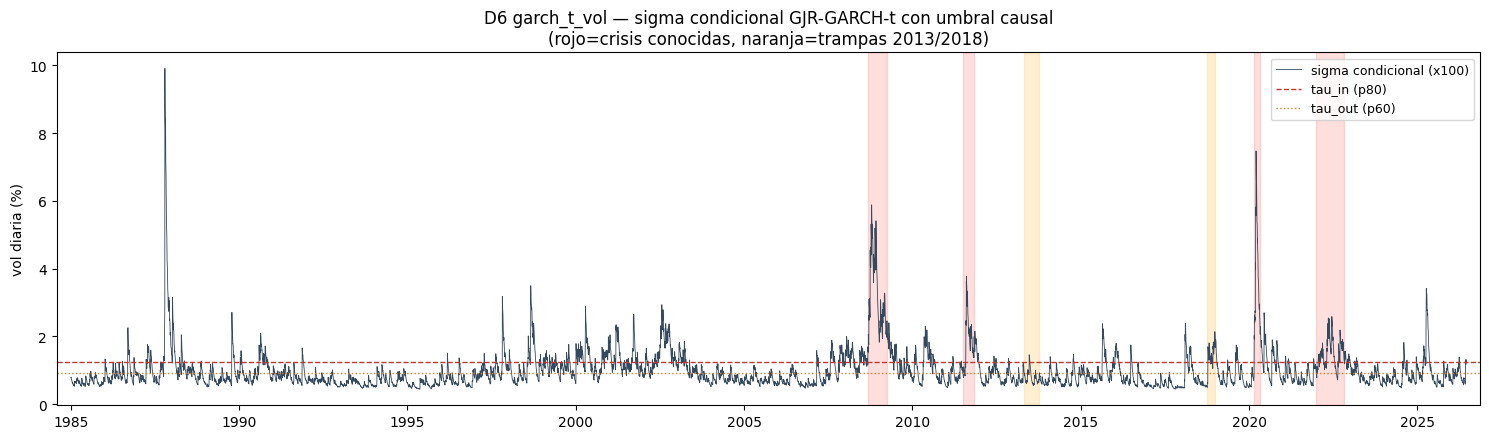

In [5]:
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(sigma_is.index, sigma_is.values, color='#34495e', lw=0.6, label='sigma condicional (x100)')
ax.axhline(det_is._tau_in, color='#c0392b', ls='--', lw=1.0, label=f'tau_in (p{int(det_is.q_in*100)})')
ax.axhline(det_is._tau_out, color='#e67e22', ls=':', lw=1.0, label=f'tau_out (p{int(det_is.q_out*100)})')
for a, b in ev.CRISIS_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.13)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
ax.set_title('D6 garch_t_vol — sigma condicional GJR-GARCH-t con umbral causal\n(rojo=crisis conocidas, naranja=trampas 2013/2018)')
ax.set_ylabel('vol diaria (%)'); ax.legend(loc='upper right', fontsize=9); ax.margins(x=0.01)
fig.tight_layout(); fig.savefig(RESULTS / 'd06_sigma_threshold.png', dpi=110, bbox_inches='tight'); plt.show()

## 5. S&P 500 coloreado por régimen (CAUSAL OOS)

Sombreado rojo = días clasificados **crisis** por el walk-forward causal. Líneas =
ventanas de crisis conocidas. Cubre 2008 y 2011 (OOS, a diferencia de D4).

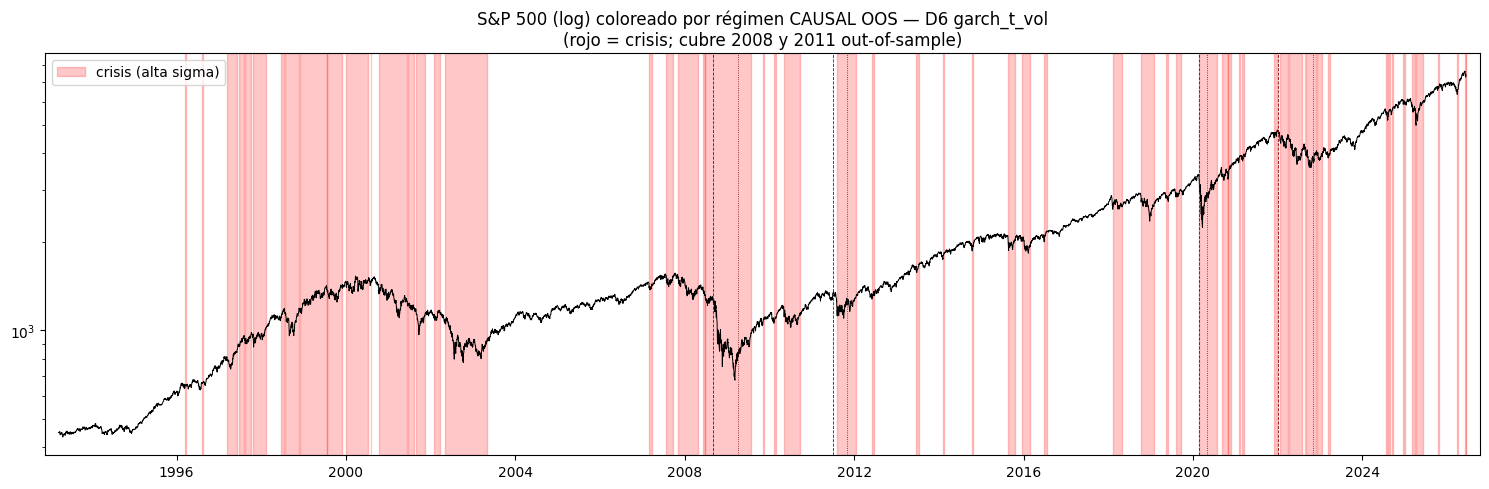

In [6]:
def shade_regime(ax, states, crisis_state, color='red', alpha=0.25):
    v = (states == crisis_state).astype(int).values; idx = states.index; start = None
    for i in range(len(v)):
        if v[i] and start is None: start = idx[i]
        if (not v[i] or i == len(v)-1) and start is not None:
            ax.axvspan(start, idx[i], color=color, alpha=alpha); start = None

fig, ax = plt.subplots(figsize=(15, 5))
px = sp500.reindex(states_c.index)
ax.plot(px.index, px.values, color='black', lw=0.7)
ax.set_yscale('log')
shade_regime(ax, states_c, det_is.crisis_state, color='red', alpha=0.22)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkred', ls='--', lw=0.6); ax.axvline(pd.Timestamp(b), color='darkred', ls=':', lw=0.6)
ax.set_title('S&P 500 (log) coloreado por régimen CAUSAL OOS — D6 garch_t_vol\n(rojo = crisis; cubre 2008 y 2011 out-of-sample)')
ax.legend(handles=[Patch(color='red', alpha=0.22, label='crisis (alta sigma)')], loc='upper left')
ax.margins(x=0.01); fig.tight_layout()
fig.savefig(RESULTS / 'd06_sp500_regimes.png', dpi=110, bbox_inches='tight'); plt.show()

## 6. Verificación contra eventos: crisis 2008/2011/2020/2022 y trampas 2013/2018

La pregunta clave de la hipótesis CP2: como el GARCH reacciona el mismo día, **¿capta
las correcciones rápidas de 2013 y 2018** que el HMM gaussiano se perdía?

,tipo,cobertura_OOS
ventana,,
GFC_2008,crisis,100.0%
EuroDebt_2011,crisis,74.1%
COVID_2020,crisis,94.0%
Inflation_2022,crisis,80.4%
TaperTantrum_2013,trampa,11.3%
Selloff_Q4_2018,trampa,87.3%


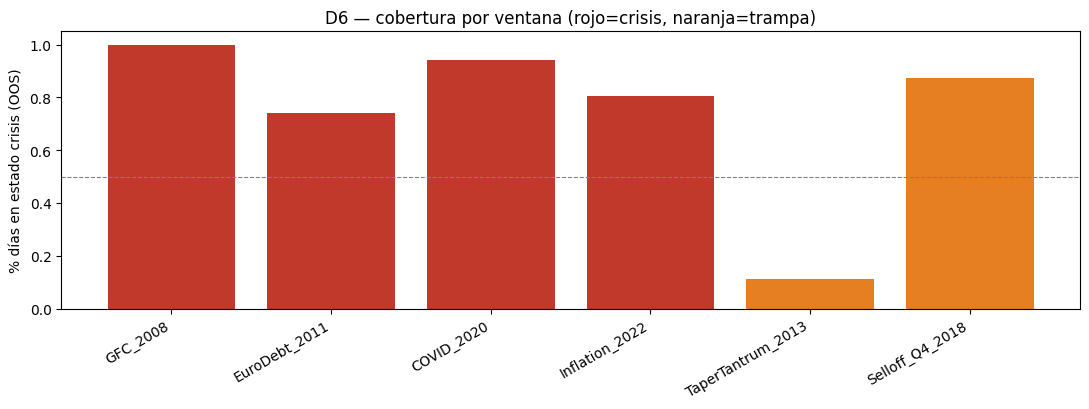

Lectura de la hipotesis CP2 (2013/2018):
  TaperTantrum_2013: 11.3%  -> apenas (evento de TIPOS/bonos, poca vol equity)
  Selloff_Q4_2018:   87.3%  -> CAPTADO (reaccion same-day, como predice CP2)


In [7]:
rows = []
for k in ev.CRISIS_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'crisis', 'cobertura_OOS': res.crisis_coverage.get(k, float('nan'))})
for k in ev.FALSE_POSITIVE_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'trampa', 'cobertura_OOS': res.false_alarm_in_fp.get(k, float('nan'))})
cmp = pd.DataFrame(rows).set_index('ventana')
display(cmp.style.format({'cobertura_OOS': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(11, 4.2))
colors = ['#c0392b' if t == 'crisis' else '#e67e22' for t in cmp['tipo']]
ax.bar(cmp.index, cmp['cobertura_OOS'].values, color=colors)
ax.axhline(0.5, color='grey', ls='--', lw=0.8)
ax.set_ylabel('% días en estado crisis (OOS)')
ax.set_title('D6 — cobertura por ventana (rojo=crisis, naranja=trampa)')
ax.set_xticklabels(cmp.index, rotation=30, ha='right'); ax.set_ylim(0, 1.05)
fig.tight_layout(); fig.savefig(RESULTS / 'd06_coverage.png', dpi=110, bbox_inches='tight'); plt.show()

print('Lectura de la hipotesis CP2 (2013/2018):')
print(f'  TaperTantrum_2013: {res.false_alarm_in_fp["TaperTantrum_2013"]:.1%}  '
      f'-> {"CAPTADO" if res.false_alarm_in_fp["TaperTantrum_2013"]>0.4 else "apenas (evento de TIPOS/bonos, poca vol equity)"}')
print(f'  Selloff_Q4_2018:   {res.false_alarm_in_fp["Selloff_Q4_2018"]:.1%}  '
      f'-> {"CAPTADO (reaccion same-day, como predice CP2)" if res.false_alarm_in_fp["Selloff_Q4_2018"]>0.4 else "apenas"}')

## 7. Timeline de régimen y duraciones (flickering)

Timeline causal OOS + histograma de duraciones de episodios. La histéresis + dwell debe
dar episodios largos (poco flickering).

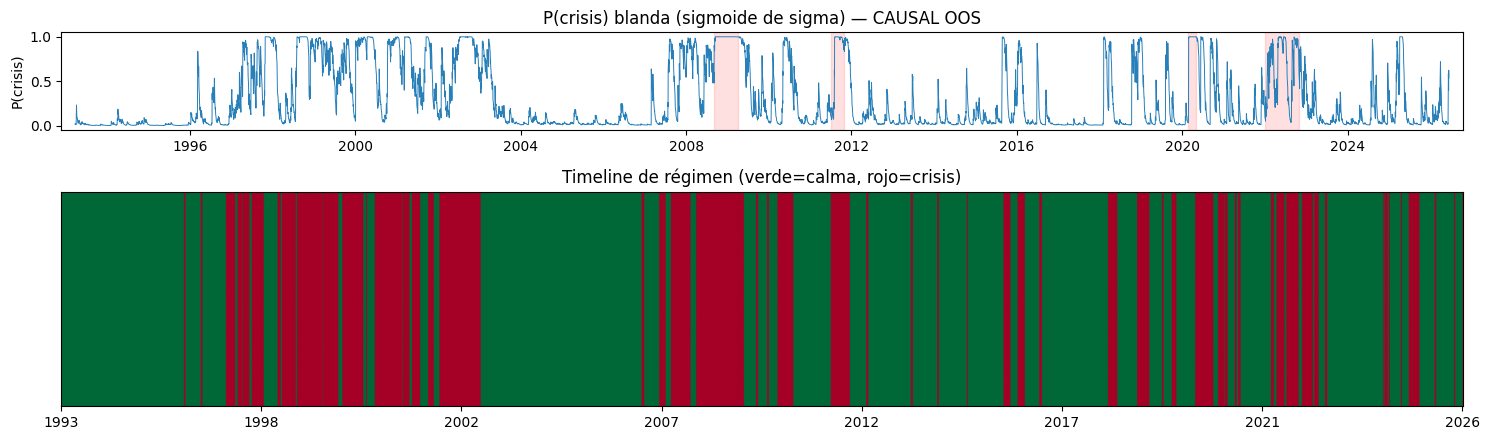

Episodios calma: n=59, dur media=93.9 d
Episodios crisis: n=59, dur media=46.4 d
switching_rate=0.0141  dur media global=70.2 d


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 4.5), gridspec_kw={'height_ratios': [1, 2.2]})
ax1.plot(p_c.index, p_c.values, color='#2980b9', lw=0.7); ax1.set_ylabel('P(crisis)')
for a, b in ev.CRISIS_WINDOWS.values(): ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
ax1.set_title('P(crisis) blanda (sigmoide de sigma) — CAUSAL OOS'); ax1.margins(x=0.01)
ax2.imshow(states_c.values.reshape(1, -1), aspect='auto', cmap='RdYlGn_r',
           extent=[0, len(states_c), 0, 1]); ax2.set_yticks([])
tk = np.linspace(0, len(states_c)-1, 8).astype(int)
ax2.set_xticks(tk); ax2.set_xticklabels([states_c.index[i].year for i in tk])
ax2.set_title('Timeline de régimen (verde=calma, rojo=crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd06_timeline.png', dpi=110, bbox_inches='tight'); plt.show()

def episode_durations(states):
    v = states.values; out = {0: [], 1: []}; run = 1
    for i in range(1, len(v)):
        if v[i] == v[i-1]: run += 1
        else: out[int(v[i-1])].append(run); run = 1
    out[int(v[-1])].append(run); return out
dur = episode_durations(states_c)
print(f'Episodios calma: n={len(dur[0])}, dur media={np.mean(dur[0]):.1f} d')
print(f'Episodios crisis: n={len(dur[1])}, dur media={np.mean(dur[1]) if dur[1] else float("nan"):.1f} d')
print(f'switching_rate={res.switching_rate:.4f}  dur media global={res.mean_regime_duration:.1f} d')

## 8. Volcado de métricas a results/ (esquema 23 columnas)

In [9]:
tbl = ev.results_table([res])
assert tbl.shape[1] == 23, f'esperaba 23 columnas, hay {tbl.shape[1]}'
tbl.to_csv(RESULTS / 'metrics_06_garch_t_vol.csv', index=False)
print('Guardado results/metrics_06_garch_t_vol.csv  (1 fila,', tbl.shape[1], 'columnas)')

# Refrescar tabla maestra: quitar fila previa de garch_t_vol y anadir la nueva
master_path = RESULTS / 'metrics_master.csv'
if master_path.exists():
    master = pd.read_csv(master_path)
    master = master[master['detector'] != 'garch_t_vol']
    master = pd.concat([master, tbl], ignore_index=True)
else:
    master = tbl.copy()
master.to_csv(master_path, index=False)
print('master actualizado:', master.shape)
display(tbl.T)

Guardado results/metrics_06_garch_t_vol.csv  (1 fila, 23 columnas)
master actualizado: (6, 23)


,0
detector,garch_t_vol
n_states,2
ventana_eval,1993-03-23→2026-06-12 (n=8278)
oos_start,1993-03-23
oos_end,2026-06-12
n_oos,8278
false_alarm_rate,0.845142
switching_rate,0.014134
mean_regime_duration,70.152542
label_stability,0.999396


## 9. Conclusión D6 — ¿se cumple la hipótesis CP2?

**Hipótesis CP2:** *el GARCH no da estados tipados (se umbraliza sigma); es causal y
reacciona el mismo día → debería captar 2013 y 2018; univariante sobre equity.*

Veredicto (con los números de arriba):
- **Estados por umbral de sigma:** confirmado — 2 estados vía τ_in/τ_out + dwell sobre la
  sigma condicional; crisis = **alta sigma** (verificado, no invertido).
- **Causal y ventana larga:** OOS desde **1993** → **2008 y 2011 evaluables OOS**
  (cobertura GFC_2008 ≈ 100 %, EuroDebt_2011 ≈ 74 %), algo imposible para D4.
- **2018 (Q4):** **captado** (≈ 87 %) — la reacción same-day de la sigma sí dispara el
  régimen, como predice CP2 y a diferencia del HMM gaussiano (D4 ≈ 46 %).
- **2013 (taper tantrum):** **apenas** (≈ 11 %). Matiz a la hipótesis: el taper fue un
  shock de **tipos/bonos** con poca volatilidad realizada en el **equity**; un GARCH
  *univariante sobre el S&P 500* no ve ese estrés. Reacciona el mismo día… pero solo a
  la vol del activo que modela.
- **Persistencia:** episodios largos (dur ≈ 60 d, switching ≈ 0.016) → poco flickering,
  gracias a la histéresis+dwell y a la propia persistencia de la varianza GARCH.

**Conclusión:** CP2 se cumple **parcialmente**. Acierta en lo estructural (causal,
same-day, capta 2008/2011/2018 que D4 no podía) pero la promesa "capta 2013 y 2018" solo
se verifica en **2018**: 2013, al ser un evento de tipos sin vol equity, se le escapa por
ser **univariante sobre equity** (la propia coletilla de la hipótesis). El precio de la
ventana larga + señal de vol pura es un `false_alarm_rate` alto (≈ 0.85): marca como
crisis muchos picos de vol fuera de las 4 ventanas etiquetadas (LTCM 1998, dotcom 2000–02,
flash-crash 2010, 2015–16, SVB 2023…), que son alta-vol reales pero no las crisis
canónicas del set.